# Primeiro Exercício Usando o Keras

Nesse exercício, vocês devem preencher os campos de código deixados em branco para realizar as seguintes tarefas:

- Exploração de dados
- Criando e treinando uma rede neural
- visualizar acurácia e erro

Faça o download da base de dados [aqui](https://drive.google.com/file/d/1GfvKA0qznNVknghV4botnNxyH-KvODOC/view), e faça o upload dentro do Colab.

## Exploração dos Dados

Usnado o pandas para ler a base de dados:

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('housepricedata.csv')

In [3]:
df

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1
...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,5,953,2,1,3,7,1,460,1
1456,13175,6,6,1542,2,0,3,7,2,500,1
1457,9042,7,9,1152,2,0,4,9,2,252,1
1458,9717,5,6,1078,1,0,2,5,0,240,0


As colunas do Data Frame do pandas podem ser acessadas com o `.values`, obtendo vetores do numpy:

In [4]:
dataset = df.values

In [5]:
dataset

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]], shape=(1460, 11))

Vamos usar as primeiras `10` colunas como input e a última coluna como output do modelo.

In [6]:
X = dataset[:,0:10]
Y = dataset[:,10]

Vamos separar a base de dados entre treino e teste e normalizar os dados usando o método [min-max](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) do scikit-learn para deixar todas as colunas entre `0` e `1`.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

Vamos separar os dados entre treino, teste e validação.

In [8]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X, Y, test_size=0.3)

In [9]:
# Separe a *_val_and_test em teste e validação
X_val, X_test, Y_val, Y_test = train_test_split( X_val_and_test, Y_val_and_test, test_size=0.5)

In [10]:
# Preencha os campos com o código correto.

min_max_scaler = preprocessing.MinMaxScaler()

# Usamos a base de treino para fit do scaler, já transformamos também
X_train = min_max_scaler.fit_transform(X_train)

In [11]:
X_train

array([[0.03695342, 0.55555556, 0.5       , ..., 0.36363636, 0.33333333,
        0.33568406],
       [0.03875295, 0.77777778, 0.5       , ..., 0.54545455, 0.33333333,
        0.60084626],
       [0.05797752, 0.66666667, 0.5       , ..., 0.27272727, 0.33333333,
        0.59449929],
       ...,
       [0.02196826, 0.44444444, 0.5       , ..., 0.18181818, 0.        ,
        0.17630465],
       [0.05630419, 0.66666667, 0.5       , ..., 0.54545455, 0.33333333,
        0.41607898],
       [0.02374442, 0.44444444, 0.625     , ..., 0.18181818, 0.33333333,
        0.19746121]], shape=(1022, 10))

In [12]:
# Aplica o scaler na base de teste e validação

X_test = min_max_scaler.transform(X_test)
X_val = min_max_scaler.transform(X_val)

In [13]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(1022, 10) (219, 10) (219, 10) (1022,) (219,) (219,)


## Criando e treinando a rede neural

In [15]:
from keras.models import Sequential
from keras.layers import Dense

Vamos usar o modelo `Sequential` do Keras, que cria redes neurais `feed-forward`, onde uma camada 'e input da seguinte. Vamos criar uma rede neural com tr^es camadas:

- Hidden layer 1: 32 neurônios, função de ativação `ReLU`
- Hidden layer 2: 32 neurônions, função de ativação `ReLU`
- Output Layer: 1 neurônio, função de ativação `Sigmoid`

A primeira camada deve ter o parâmetro `input_shape` que determina as dimensões esperadas dos dados de entrada. No nosso caso, temos `10` colunas nos dados (sendo 10 variáveis).

Vamos utilizar a função de ativição "sigmoid" na camada de output.

In [18]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])

### Visualizando a rede neural

Mostrando os parâmetros e detalhes da rede em forma tabular com o método `.summary()`.

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

Utilizando a função `plot_model` do módulo `utils`.

In [24]:
from keras.utils import plot_model

In [ ]:
plot_model(model, show_layer_activations=True, show_shapes=True)

### Treinando o modelo

Antes de começar a treinar a rede neural, vamos definir:
- Algorítmo de otimização (vamos usar o `stochastic gradient descent`)
- Qual função de perda ("loss function") utilizar (depende da aplicação, para classificação binária podemos usar `binary cross entropy`)
- Adicionar métricas de  performance para ser adicionadas nos logs (vamos usar `accuracy`)

In [26]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Parecido com o scikit-learn, usamos o método `.fit()`:
- Passamos a base de treino e validação
- O tamanho do batch
- Qauntas épocas usar (epochs)

O retorno da função é um objeto `history` que contém informação do treino.

In [29]:
hist = model.fit(
    X_train, Y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, Y_val)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4990 - loss: 0.6926 - val_accuracy: 0.5251 - val_loss: 0.6855
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5049 - loss: 0.6889 - val_accuracy: 0.5297 - val_loss: 0.6816
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5108 - loss: 0.6851 - val_accuracy: 0.5616 - val_loss: 0.6777
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5176 - loss: 0.6815 - val_accuracy: 0.5936 - val_loss: 0.6739
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5470 - loss: 0.6778 - val_accuracy: 0.6119 - val_loss: 0.6702
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6086 - loss: 0.6742 - val_accuracy: 0.6301 - val_loss: 0.6662
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6184 - loss: 0.6704 - val_accuracy: 0.6712 - val_loss: 0.6620
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6517 - loss: 0.6663 - val_accuracy: 0.6895 - 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7290 - loss: 0.6565 - val_accuracy: 0.7626 - val_loss: 0.6468
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7485 - loss: 0.6506 - val_accuracy: 0.7717 - val_loss: 0.6405
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7661 - loss: 0.6448 - val_accuracy: 0.7717 - val_loss: 0.6341
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7798 - loss: 0.6386 - val_accuracy: 0.8037 - val_loss: 0.6274
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7808 - loss: 0.6320 - val_accuracy: 0.8174 - val_loss: 0.6204
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7828 - loss: 0.6251 - val_accuracy: 0.8128 - val_loss: 0.6131
Epoch 16/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7935 - loss: 0.6180 - val_accuracy: 0.8174 - val_loss: 0.6050
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8033 - loss: 0.6103 - val_accuracy: 0.8311 - val_lo

Vamos avaliar o modelo na base de teste (que não foi usada no treino):

In [30]:
model.evaluate(X_test, Y_test)[1]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8676 - loss: 0.3320 


0.8675799369812012

# Visualização

In [33]:
import matplotlib.pyplot as plt

Vamos criar um plot dos valores de erro do modulo durante o treino, nas bases de treino e validação, usando os dados em `loss` e `val_loss`.

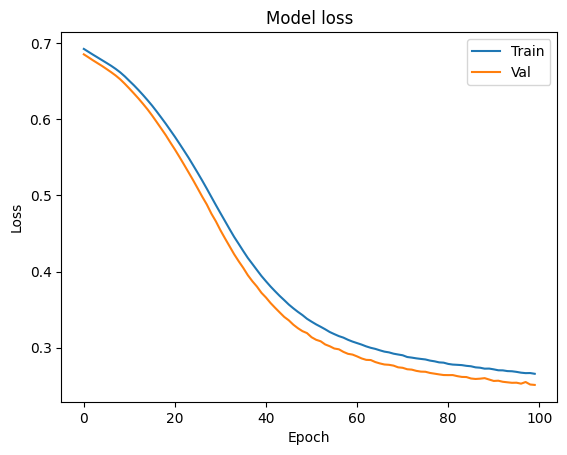

In [34]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

E a acurácia também com os valores em `accuracy` e `val_accuracy`:

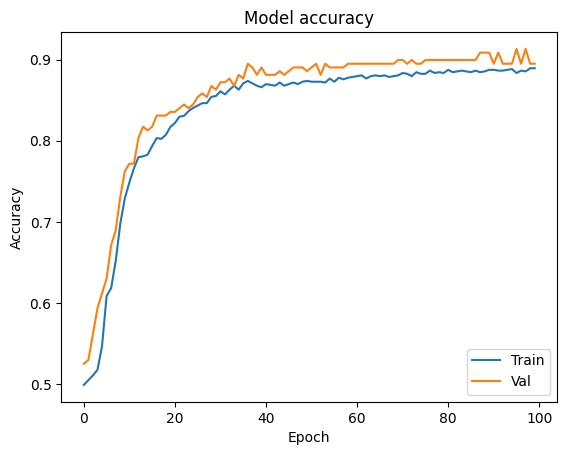

In [35]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

**Para pensar: O que aconteceu no erro e na acurácio do modelo conforme treinamos por mais de 40 épocas?**